In [ ]:
import os

%cd /content
!rm -rf SMADIMO_GP5

#!git clone

%cd SMADIMO_GP5
!git checkout eda/oskelly

In [10]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
DATA_DIR = "/content/SMADIMO_GP5/data/raw/oskelly_dataset.xlsx"

In [13]:
df = pd.read_excel(DATA_DIR)

print(df.shape)
print(df.columns.tolist())

(9600, 23)
['Oskelly ID', 'url', 'Размер', 'Раздел', 'Категория', 'Бренд', 'Материал одежды', 'Цвет', 'Состояние товара', 'Продавец', 'Цена', 'Скидка', 'Описание', 'Название', 'Состояние', 'image_url', 'image_path', 'Посадка', 'Материал джинсов', 'Модель', 'Винтаж', 'Материал футболок', 'Материал рубашек']


In [14]:
df.head(3)

,Oskelly ID,url,Размер,Раздел,Категория,Бренд,Материал одежды,Цвет,Состояние товара,Продавец,...,Название,Состояние,image_url,image_path,Посадка,Материал джинсов,Модель,Винтаж,Материал футболок,Материал рубашек
0,3136231,https://oskelly.ru/products/pukhovik-brunelloc...,IT 40,Женское,Пуховики,BRUNELLO CUCINELLI,Кожа,Розовый,Отличное состояние,Частный продавец,...,BRUNELLO CUCINELLIРозовый кожаный пуховикРозов...,Отличное состояние,https://static.cdn.oskelly.ru/product/3136231/...,D:\GP5\oskelly_images\3136231.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1,3653158,https://oskelly.ru/products/dzhemper--sviter-b...,IT 40,Женское,Джемперы и свитеры,BRUNELLO CUCINELLI,Кашемир,Серый,Отличное состояние,Частный продавец,...,BRUNELLO CUCINELLIСерый кашемировый джемпер / ...,Отличное состояние,https://static.cdn.oskelly.ru/product/3653158/...,D:\GP5\oskelly_images\3653158.jpg,NaN,NaN,NaN,NaN,NaN,NaN
2,5392952,https://oskelly.ru/products/bryuki-uzkie-twin-...,IT 40/42/44,Женское,Брюки узкие,TWIN-SET,Вискоза,Темно-синий,Новое с биркой,Бутик,...,TWIN-SETТемно-синие вискозные брюки узкиеТемно...,Новое с биркой,https://static.cdn.oskelly.ru/product/5392952/...,D:\GP5\oskelly_images\5392952.jpg,Средняя,NaN,NaN,NaN,NaN,NaN


Посмотрим на пропуски

In [15]:
print(df.isnull().sum().sort_values(ascending=False))

Винтаж               9515
Модель               9457
Материал рубашек     9099
Материал джинсов     9074
Посадка              8095
Материал футболок    7997
Материал одежды      2697
Скидка               1733
Описание                3
image_path              1
Категория               0
Oskelly ID              0
url                     0
Раздел                  0
Размер                  0
Бренд                   0
Название                0
Состояние               0
Цена                    0
Состояние товара        0
Цвет                    0
Продавец                0
image_url               0
dtype: int64


Почистим некоторые ключевые признаки. Избавимся от лишних пробелов и пропусков

In [16]:
df["Скидка"] = (df["Скидка"].fillna(0).astype(str).str.replace("%", "", regex=False).astype(int).abs())

In [17]:
df['Описание'] = df['Описание'].fillna('').str.strip()

In [18]:
df['Название'] = df['Название'].fillna('').str.strip()

In [19]:
df['Состояние товара'] = df['Состояние товара'].str.strip()

Удалим дубликаты по ИД

In [20]:
df = df.drop_duplicates(subset='Oskelly ID')

In [21]:
df.head()

,Oskelly ID,url,Размер,Раздел,Категория,Бренд,Материал одежды,Цвет,Состояние товара,Продавец,...,Название,Состояние,image_url,image_path,Посадка,Материал джинсов,Модель,Винтаж,Материал футболок,Материал рубашек
0,3136231,https://oskelly.ru/products/pukhovik-brunelloc...,IT 40,Женское,Пуховики,BRUNELLO CUCINELLI,Кожа,Розовый,Отличное состояние,Частный продавец,...,BRUNELLO CUCINELLIРозовый кожаный пуховикРозов...,Отличное состояние,https://static.cdn.oskelly.ru/product/3136231/...,D:\GP5\oskelly_images\3136231.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1,3653158,https://oskelly.ru/products/dzhemper--sviter-b...,IT 40,Женское,Джемперы и свитеры,BRUNELLO CUCINELLI,Кашемир,Серый,Отличное состояние,Частный продавец,...,BRUNELLO CUCINELLIСерый кашемировый джемпер / ...,Отличное состояние,https://static.cdn.oskelly.ru/product/3653158/...,D:\GP5\oskelly_images\3653158.jpg,NaN,NaN,NaN,NaN,NaN,NaN
2,5392952,https://oskelly.ru/products/bryuki-uzkie-twin-...,IT 40/42/44,Женское,Брюки узкие,TWIN-SET,Вискоза,Темно-синий,Новое с биркой,Бутик,...,TWIN-SETТемно-синие вискозные брюки узкиеТемно...,Новое с биркой,https://static.cdn.oskelly.ru/product/5392952/...,D:\GP5\oskelly_images\5392952.jpg,Средняя,NaN,NaN,NaN,NaN,NaN
3,3904378,https://oskelly.ru/products/bluzy-brunellocuci...,INT S,Женское,Блузы,BRUNELLO CUCINELLI,Шелк,Мульти,Отличное состояние,Частный продавец,...,BRUNELLO CUCINELLIМульти шелковая блузыМульти ...,Отличное состояние,https://static.cdn.oskelly.ru/product/3904378/...,D:\GP5\oskelly_images\3904378.jpg,NaN,NaN,NaN,NaN,NaN,NaN
4,4034222,https://oskelly.ru/products/yubka-maksi-brunel...,IT 38,Женское,Юбки макси,BRUNELLO CUCINELLI,Шелк,Серый,Новое с биркой,Частный продавец,...,BRUNELLO CUCINELLIСерая шелковая юбка максиСер...,Новое с биркой,https://static.cdn.oskelly.ru/product/4034222/...,D:\GP5\oskelly_images\4034222.jpg,NaN,NaN,NaN,NaN,NaN,NaN


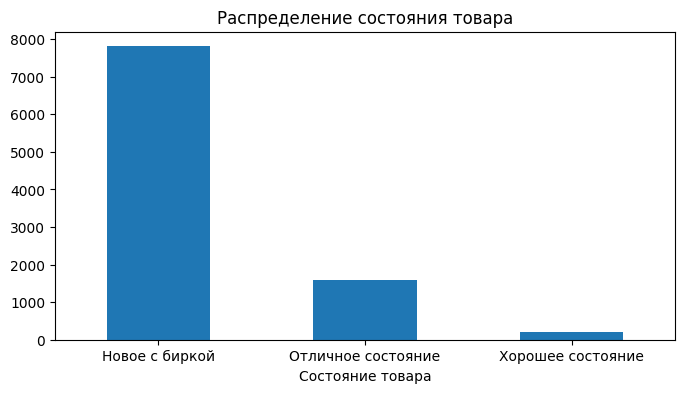

In [22]:
df["Состояние товара"].value_counts().plot(kind="bar", figsize=(8, 4))
plt.title("Распределение состояния товара")
plt.xticks(rotation=0)
plt.show()

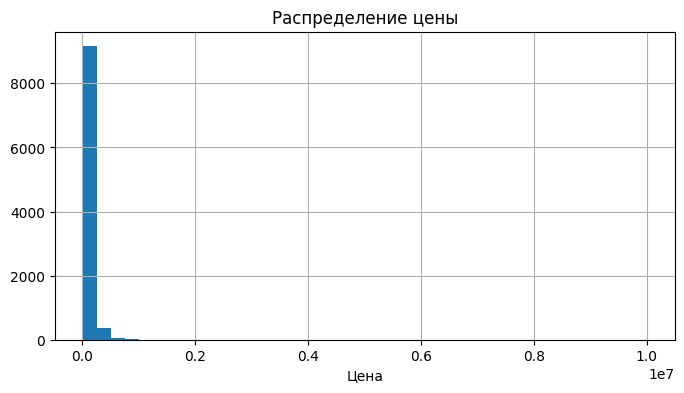

count        9600.0
mean        83754.0
std        213758.0
min          9996.0
25%         25971.0
50%         47212.0
75%         90276.0
max      10000000.0
Name: Цена, dtype: float64


In [23]:
df["Цена"].hist(bins=40, figsize=(8, 4))
plt.title("Распределение цены")
plt.xlabel("Цена")
plt.show()
print(df["Цена"].describe().round(0))

Распределение цены имеет большой правый хвост. Попробуем прологарифмировать

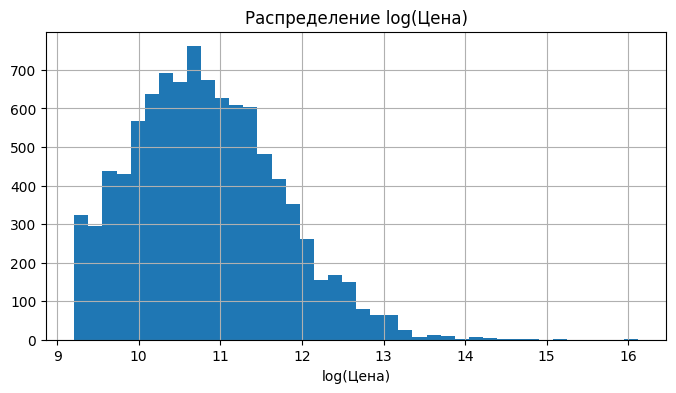

count        9600.0
mean        83754.0
std        213758.0
min          9996.0
25%         25971.0
50%         47212.0
75%         90276.0
max      10000000.0
Name: Цена, dtype: float64


In [24]:
np.log1p(df["Цена"]).hist(bins=40, figsize=(8, 4))
plt.title("Распределение log(Цена)")
plt.xlabel("log(Цена)")
plt.show()
print(df["Цена"].describe().round(0))

Цены распределены неравномерно

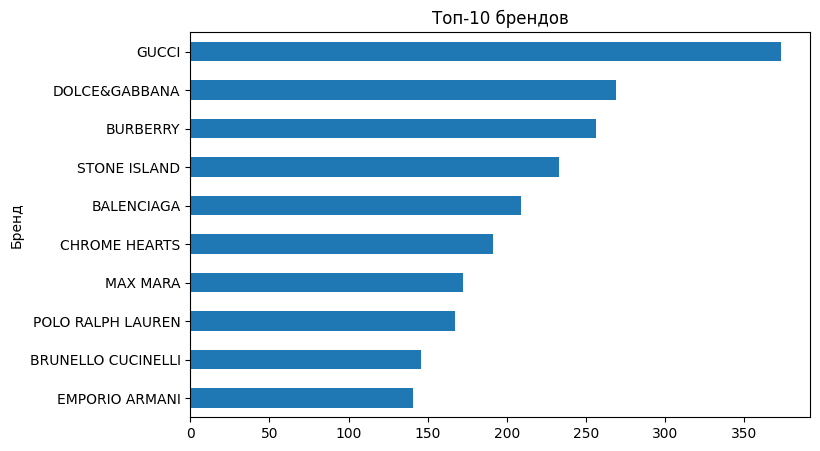

In [25]:
df["Бренд"].value_counts().head(10).plot(kind="barh", figsize=(8, 5))
plt.title("Топ-10 брендов")
plt.gca().invert_yaxis()
plt.show()

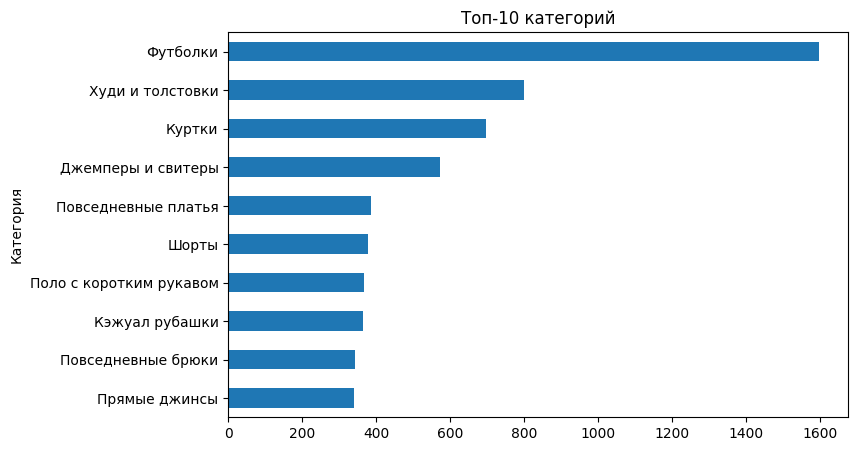

In [26]:
df["Категория"].value_counts().head(10).plot(kind="barh", figsize=(8, 5))
plt.title("Топ-10 категорий")
plt.gca().invert_yaxis()
plt.show()

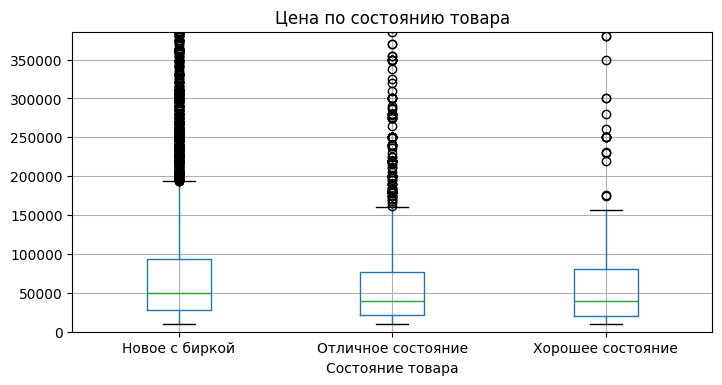

In [27]:
df.boxplot(column="Цена", by="Состояние товара", figsize=(8, 4))
plt.ylim(0, df["Цена"].quantile(0.98))
plt.title("Цена по состоянию товара")
plt.suptitle("")
plt.show()

In [29]:
!git config --global user.email "salyukov-sava@yandex.ru"
!git config --global user.name "Savely"


In [35]:
!cp "/drive/MyDrive/название_ноутбука.ipynb" /content/SMADIMO_GP5/notebooks/

Mounted at /drive


In [28]:
!git add notebooks/GP5_EDA.ipynb
!git commit -m "Первый просмотр данных и графики"
!git push origin eda/oskelly

fatal: pathspec 'notebooks/GP5_EDA.ipynb' did not match any files
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@0231f00b5c14.(none)')
fatal: could not read Password for 'https://ghp_...@github.com': No such device or address
